In [3]:
import pandas as pd
import numpy as np

# Настройки отображения, чтобы удобнее смотреть датафреймы
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Если файлы лежат в текущей папке ноутбука:
train_path = "train.csv"
test_path = "test.csv"

# Имя колонки с датой по условию
date_columns = ["ApplicationDate"]

train = pd.read_csv(
    train_path,
    parse_dates=date_columns,
    low_memory=False
)

test = pd.read_csv(
    test_path,
    parse_dates=date_columns,
    low_memory=False
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (11017, 35)
Test shape: (5000, 35)


In [4]:
display(train.head())
train.info()

display(test.head())
test.info()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,0.151985,2.0,1.0,0.168542,0.0,Education,0.0,23.0,5.0,2539.0,247.0,50072.0,15005.0,5569.083333,0.908289,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,0.175693,3.0,0.0,0.141553,0.0,Home,0.0,27.0,11.0,844.0,694.0,91878.0,64877.0,14345.583333,0.797339,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,0.444605,3.0,0.0,0.030987,1.0,Education,0.0,21.0,12.0,12756.0,651.0,292300.0,13918.0,25000.000000,0.915945,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,0.188452,7.0,0.0,0.379843,0.0,Debt Consolidation,0.0,27.0,21.0,1524.0,529.0,13070.0,3846.0,2890.250000,0.876416,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,0.273431,3.0,1.0,0.068659,0.0,Debt Consolidation,0.0,35.0,9.0,1973.0,128.0,33357.0,351603.0,25000.000000,0.888689,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ApplicationDate             10487 non-null  datetime64[ns]
 1   Age                         10487 non-null  float64       
 2   AnnualIncome                10487 non-null  float64       
 3   CreditScore                 9986 non-null   float64       
 4   LoanAmount                  9986 non-null   float64       
 5   LoanDuration                10487 non-null  float64       
 6   MaritalStatus               10487 non-null  object        
 7   NumberOfDependents          10487 non-null  float64       
 8   HomeOwnershipStatus         10487 non-null  object        
 9   MonthlyDebtPayments         9986 non-null   float64       
 10  CreditCardUtilizationRate   10487 non-null  float64       
 11  NumberOfOpenCreditLines     10487 non-null  float64   

,ID,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,0,1979-01-03,49,207095,850,14458,60,Single,0,Rent,376,0.077124,2,0,0.438186,0,Auto,0,28,15,5008,619,5627,25585,17257.916667,0.883232,6,Employed,High School,23,10626,0.104458,0.125350,325.532336,0.040650
1,1,2006-04-10,28,64653,674,65491,48,Single,2,Own,238,0.073977,4,2,0.446233,0,Education,0,23,28,4590,710,317306,18282,5387.750000,0.791928,3,Employed,High School,3,299024,0.233491,0.260561,2210.247757,0.454410
2,2,2013-11-28,41,300000,768,16811,60,Single,1,Own,469,0.331499,5,0,0.035313,0,Auto,0,23,9,2429,623,13115,6136,25000.000000,0.805826,3,Employed,High School,19,6979,0.147811,0.154571,403.977431,0.034919
3,3,1995-08-24,50,300000,850,48737,36,Divorced,0,Mortgage,567,0.544696,2,1,0.278922,0,Education,0,24,9,14571,10749,25320,93806,25000.000000,0.829294,3,Self-Employed,Bachelor,26,8438,0.118737,0.099712,1571.946906,0.085558
4,4,1980-06-15,35,300000,672,51916,60,Single,6,Mortgage,106,0.436103,0,0,0.196376,0,Home,0,14,6,930,2926,439068,2852,25000.000000,0.735013,7,Employed,Associate,12,436216,0.230916,0.237727,1486.675235,0.063707


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ID                          5000 non-null   int64         
 1   ApplicationDate             5000 non-null   datetime64[ns]
 2   Age                         5000 non-null   int64         
 3   AnnualIncome                5000 non-null   int64         
 4   CreditScore                 5000 non-null   int64         
 5   LoanAmount                  5000 non-null   int64         
 6   LoanDuration                5000 non-null   int64         
 7   MaritalStatus               5000 non-null   object        
 8   NumberOfDependents          5000 non-null   int64         
 9   HomeOwnershipStatus         5000 non-null   object        
 10  MonthlyDebtPayments         5000 non-null   int64         
 11  CreditCardUtilizationRate   5000 non-null   float64     

In [5]:
# 1. Разделяем признаки по типам в train
numeric_features = train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = train.select_dtypes(include=["object"]).columns.tolist()
date_features = train.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

print("Numeric features (train):", len(numeric_features))
print(numeric_features)
print("\nCategorical features (train):", len(categorical_features))
print(categorical_features)
print("\nDate features (train):", len(date_features))
print(date_features)

# 2. Таблица пропусков по train
missing_counts = train.isnull().sum()
missing_percent = missing_counts / len(train)

missing_df = (
    pd.DataFrame({
        "missing_count": missing_counts,
        "missing_percent": (missing_percent * 100).round(2)
    })
    .sort_values("missing_percent", ascending=False)
)

missing_df

Numeric features (train): 29
['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'Experience', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore']

Categorical features (train): 5
['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel']

Date features (train): 1
['ApplicationDate']


,missing_count,missing_percent
MonthlyDebtPayments,1031,9.36
LoanAmount,1031,9.36
CreditScore,1031,9.36
BaseInterestRate,1031,9.36
NetWorth,1031,9.36
TotalAssets,1031,9.36
BankruptcyHistory,1031,9.36
LoanPurpose,1031,9.36
CheckingAccountBalance,1031,9.36
ApplicationDate,530,4.81


count    1.048700e+04
mean    -2.569878e+04
std      1.431675e+06
min     -9.999999e+06
25%      3.256475e+01
50%      4.411876e+01
75%      6.535690e+01
max      1.000000e+07
Name: RiskScore, dtype: float64


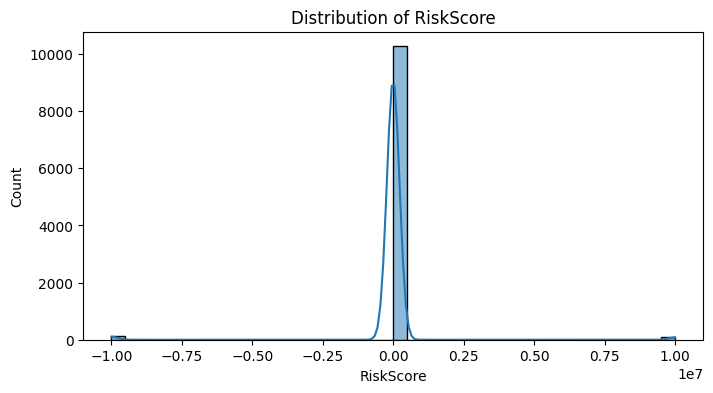

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Базовая статистика по таргету
print(train["RiskScore"].describe())

# 2. Гистограмма + KDE
plt.figure(figsize=(8, 4))
sns.histplot(train["RiskScore"], kde=True, bins=40)
plt.title("Distribution of RiskScore")
plt.xlabel("RiskScore")
plt.ylabel("Count")
plt.show()

Top correlations with RiskScore:


,RiskScore
NumberOfDependents,-0.023314
PaymentHistory,0.019144
TotalDebtToIncomeRatio,0.013879
UtilityBillsPaymentHistory,-0.013865
MonthlyLoanPayment,0.012366
LoanAmount,0.011771
NumberOfCreditInquiries,0.011055
LengthOfCreditHistory,-0.009448
NetWorth,0.008804
AnnualIncome,-0.008460


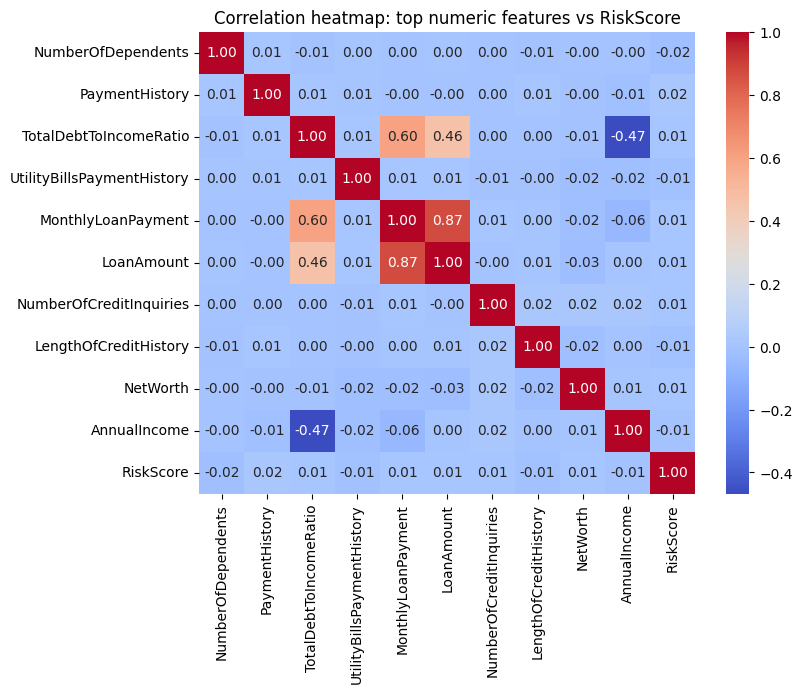

In [7]:
# Берём только числовые признаки (кроме самого ID, которого нет в train)
numeric_features_no_target = [col for col in numeric_features if col != "RiskScore"]

# Матрица корреляций только по числовым
corr_matrix = train[numeric_features].corr()

# Корреляции признаков с таргетом, отсортированные по модулю
target_corr = (
    corr_matrix["RiskScore"]
    .drop("RiskScore")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Top correlations with RiskScore:")
display(target_corr.head(15))

# Небольшая heatmap по 10 самым связанным признакам
top_features = target_corr.head(10).index.tolist() + ["RiskScore"]

plt.figure(figsize=(8, 6))
sns.heatmap(train[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap: top numeric features vs RiskScore")
plt.show()


=== MaritalStatus ===


,count,mean,median
MaritalStatus,,,
Widowed,563,-53239.512976,41.948392
Divorced,1562,-38365.420022,42.792435
Single,3217,-24820.259076,44.678644
Married,5145,-19388.870617,44.435615



=== HomeOwnershipStatus ===


,count,mean,median
HomeOwnershipStatus,,,
Mortgage,4148,-40936.542915,43.598617
Own,2116,-33033.509893,43.880229
Rent,3186,-21923.664612,44.970516
Other,1037,38620.383552,44.118758



=== LoanPurpose ===


,count,mean,median
LoanPurpose,,,
Other,948,-105437.622090,45.713645
Auto,2010,-29803.409393,44.656181
Debt Consolidation,2446,-28570.963677,43.035866
Home,2981,-26789.748152,42.762023
Education,1601,48.625549,45.868615



=== EmploymentStatus ===


,count,mean,median
EmploymentStatus,,,
Unemployed,436,-137564.736425,47.814047
Employed,9059,-23134.274999,43.885747
Self-Employed,992,48.868588,44.435614



=== EducationLevel ===


,count,mean,median
EducationLevel,,,
Bachelor,3092,-58167.669571,43.134658
High School,4234,-33017.587738,46.216446
Associate,2057,9770.296566,44.189388
Master,755,13290.887807,39.667639
Doctorate,349,57351.392009,37.939884


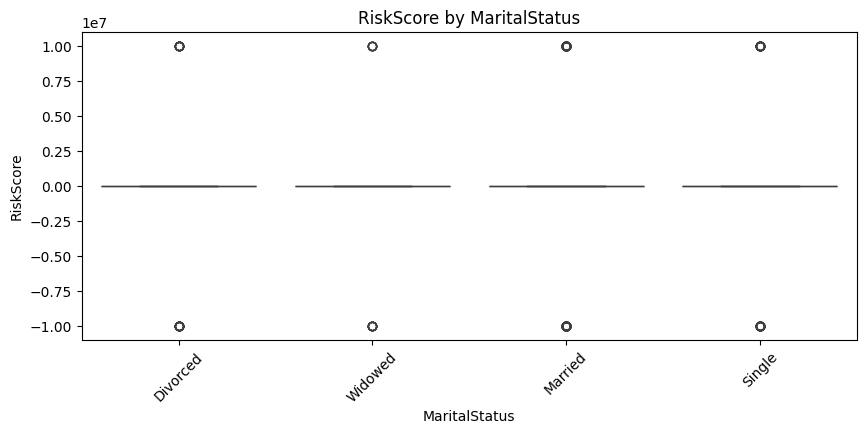

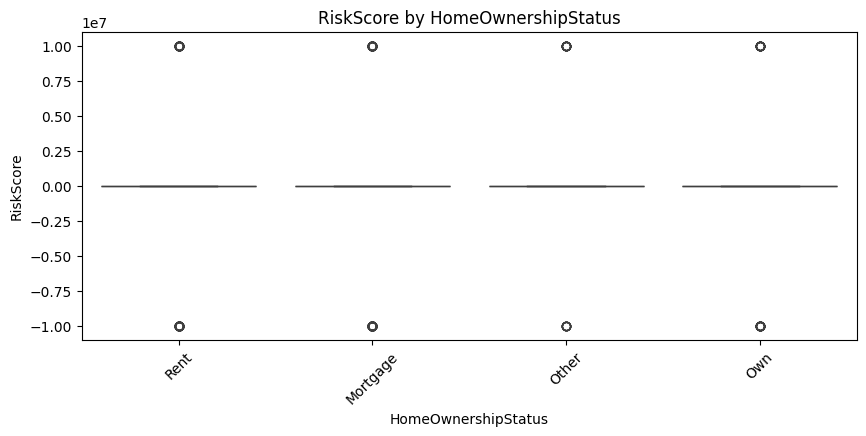

In [8]:
# Список интересных категориальных признаков
cat_cols_to_check = ["MaritalStatus", "HomeOwnershipStatus", "LoanPurpose",
                     "EmploymentStatus", "EducationLevel"]

# 1. Средний и медианный RiskScore по категориям
for col in cat_cols_to_check:
    print(f"\n=== {col} ===")
    display(
        train.groupby(col)["RiskScore"]
             .agg(["count", "mean", "median"])
             .sort_values("mean")
    )

# 2. Боксплоты для пары признаков
plt.figure(figsize=(10, 4))
sns.boxplot(data=train, x="MaritalStatus", y="RiskScore")
plt.title("RiskScore by MaritalStatus")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=train, x="HomeOwnershipStatus", y="RiskScore")
plt.title("RiskScore by HomeOwnershipStatus")
plt.xticks(rotation=45)
plt.show()

In [9]:
# Считаем квартильные значения и IQR для RiskScore
q1 = train["RiskScore"].quantile(0.25)
q3 = train["RiskScore"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3 * iqr
upper_bound = q3 + 3 * iqr

print("Q1:", q1, "Q3:", q3, "IQR:", iqr)
print("Lower bound:", lower_bound, "Upper bound:", upper_bound)

# Фильтрация выбросов
mask = (train["RiskScore"] >= lower_bound) & (train["RiskScore"] <= upper_bound)
print("Rows before:", len(train), "Rows after:", mask.sum())

train_clean = train.loc[mask].reset_index(drop=True)

Q1: 32.5647484719357 Q3: 65.35689774336566 IQR: 32.79214927142996
Lower bound: -65.81169934235419 Upper bound: 163.73334555765555
Rows before: 11017 Rows after: 10272


In [10]:
def add_date_features(df):
    df = df.copy()
    df["ApplicationYear"] = df["ApplicationDate"].dt.year
    df["ApplicationMonth"] = df["ApplicationDate"].dt.month
    # Дополнительно можно день недели:
    df["ApplicationDayOfWeek"] = df["ApplicationDate"].dt.dayofweek
    # После извлечения признаков удаляем исходную дату
    df = df.drop(columns=["ApplicationDate"])
    return df

train_clean = add_date_features(train_clean)
test_with_date_feats = add_date_features(test)

# Обновим списки признаков
numeric_features = train_clean.select_dtypes(include=["number"]).columns.tolist()
categorical_features = train_clean.select_dtypes(include=["object"]).columns.tolist()

# Уберём таргет из списка числовых
numeric_features = [col for col in numeric_features if col != "RiskScore"]

print("Numeric features (after date features):", len(numeric_features))
print("Categorical features:", categorical_features)

Numeric features (after date features): 31
Categorical features: ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel']


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

# Препроцессинг для числовых признаков
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Препроцессинг для категориальных признаков
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Объединяем всё в ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Базовый pipeline: предобработка -> линейная регрессия
linreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [12]:
X = train_clean.drop(columns=["RiskScore"])
y = train_clean["RiskScore"]

# Быстрый тест: обучим на 1000 строк и сделаем предсказание
sample_X = X.iloc[:1000]
sample_y = y.iloc[:1000]

linreg_pipeline.fit(sample_X, sample_y)
sample_preds = linreg_pipeline.predict(sample_X[:5])

print("Sample predictions:", sample_preds)
print("Sample true values:", sample_y.iloc[:5].to_list())

Sample predictions: [56.25568842 33.15857183 36.72044258 48.41791237 25.55312765]
Sample true values: [66.17650019314914, 28.495737103496538, 34.48810382302422, 36.91075291012432, 31.34709071104565]


In [13]:
from sklearn.model_selection import train_test_split

# Фичи и таргет из очищенного train
X = train_clean.drop(columns=["RiskScore"])
y = train_clean["RiskScore"]

# 80/20 сплит
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape, "Valid shape:", X_valid.shape)

# Обучаем pipeline с LinearRegression
linreg_pipeline.fit(X_train, y_train)

# Предсказания на валидации
y_valid_pred = linreg_pipeline.predict(X_valid)

Train shape: (8217, 36) Valid shape: (2055, 36)


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred, eps=1e-8):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # используем |y_true| в знаменателе и защищаемся от деления на 0
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

mse = mean_squared_error(y_valid, y_valid_pred)
mae = mean_absolute_error(y_valid, y_valid_pred)
r2 = r2_score(y_valid, y_valid_pred)
mape = mean_absolute_percentage_error(y_valid, y_valid_pred)

print(f"MSE:   {mse:.4f}")
print(f"MAE:   {mae:.4f}")
print(f"R^2:   {r2:.4f}")
print(f"MAPE:  {mape:.2f}%")

MSE:   53.8708
MAE:   5.8940
R^2:   0.8199
MAPE:  14.05%


In [15]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Pipeline: тот же препроцессинг + Ridge вместо LinearRegression
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

In [16]:
# Сетка значений alpha: от 0.001 до 1000 по логарифмической шкале
alpha_grid = np.logspace(-3, 3, 13)  # [0.001, 0.00215, ..., 1000]

param_grid = {
    "model__alpha": alpha_grid
}

ridge_grid_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",  # MSE с минусом (так устроен sklearn)
    cv=5,
    n_jobs=-1,
    verbose=1
)

ridge_grid_search.fit(X_train, y_train)

print("Best alpha:", ridge_grid_search.best_params_["model__alpha"])
print("Best CV score (neg MSE):", ridge_grid_search.best_score_)
print("Best CV MSE:", -ridge_grid_search.best_score_)

Fitting 5 folds for each of 13 candidates, totalling 65 fits
Best alpha: 10.0
Best CV score (neg MSE): -52.987334920765406
Best CV MSE: 52.987334920765406


In [17]:
# Лучший найденный пайплайн с Ridge
best_ridge_pipeline = ridge_grid_search.best_estimator_

# Предсказания на валидационной выборке
y_valid_pred_ridge = best_ridge_pipeline.predict(X_valid)

# Считаем те же метрики, что и для LinearRegression
mse_ridge = mean_squared_error(y_valid, y_valid_pred_ridge)
mae_ridge = mean_absolute_error(y_valid, y_valid_pred_ridge)
r2_ridge = r2_score(y_valid, y_valid_pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_valid, y_valid_pred_ridge)

print(f"Ridge MSE:   {mse_ridge:.4f}")
print(f"Ridge MAE:   {mae_ridge:.4f}")
print(f"Ridge R^2:   {r2_ridge:.4f}")
print(f"Ridge MAPE:  {mape_ridge:.2f}%")

Ridge MSE:   53.8488
Ridge MAE:   5.8921
Ridge R^2:   0.8199
Ridge MAPE:  14.05%


In [18]:
results = pd.DataFrame({
    "model": ["LinearRegression", "Ridge"],
    "MSE":  [mse, mse_ridge],
    "MAE":  [mae, mae_ridge],
    "R2":   [r2, r2_ridge],
    "MAPE": [mape, mape_ridge]
})
results

,model,MSE,MAE,R2,MAPE
0,LinearRegression,53.870794,5.894020,0.819862,14.052131
1,Ridge,53.848759,5.892081,0.819936,14.046476


In [19]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000, random_state=42))
])

In [20]:
# Лог-сетка alpha помельче, чем у Ridge
lasso_alpha_grid = np.logspace(-4, 1, 10)  # от 0.0001 до 10

lasso_param_grid = {
    "model__alpha": lasso_alpha_grid
}

lasso_grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

lasso_grid_search.fit(X_train, y_train)

print("Best alpha (Lasso):", lasso_grid_search.best_params_["model__alpha"])
print("Best CV score (neg MSE):", lasso_grid_search.best_score_)
print("Best CV MSE:", -lasso_grid_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best alpha (Lasso): 0.05994842503189409
Best CV score (neg MSE): -52.80030203062114
Best CV MSE: 52.80030203062114


In [21]:
best_lasso_pipeline = lasso_grid_search.best_estimator_

y_valid_pred_lasso = best_lasso_pipeline.predict(X_valid)

mse_lasso = mean_squared_error(y_valid, y_valid_pred_lasso)
mae_lasso = mean_absolute_error(y_valid, y_valid_pred_lasso)
r2_lasso = r2_score(y_valid, y_valid_pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_valid, y_valid_pred_lasso)

print(f"Lasso MSE:   {mse_lasso:.4f}")
print(f"Lasso MAE:   {mae_lasso:.4f}")
print(f"Lasso R^2:   {r2_lasso:.4f}")
print(f"Lasso MAPE:  {mape_lasso:.2f}%")

Lasso MSE:   53.8672
Lasso MAE:   5.8852
Lasso R^2:   0.8199
Lasso MAPE:  14.04%


In [22]:
results = pd.DataFrame({
    "model": ["LinearRegression", "Ridge", "Lasso"],
    "MSE":  [mse, mse_ridge, mse_lasso],
    "MAE":  [mae, mae_ridge, mae_lasso],
    "R2":   [r2, r2_ridge, r2_lasso],
    "MAPE": [mape, mape_ridge, mape_lasso]
})
results

,model,MSE,MAE,R2,MAPE
0,LinearRegression,53.870794,5.894020,0.819862,14.052131
1,Ridge,53.848759,5.892081,0.819936,14.046476
2,Lasso,53.867180,5.885246,0.819874,14.037501


In [23]:
from sklearn.linear_model import ElasticNet

elastic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

elastic_alpha_grid = np.logspace(-4, 1, 6)          # 0.0001 ... 10
elastic_l1_ratio_grid = [0.1, 0.3, 0.5, 0.7, 0.9]   # баланс L1/L2

elastic_param_grid = {
    "model__alpha": elastic_alpha_grid,
    "model__l1_ratio": elastic_l1_ratio_grid
}

elastic_grid_search = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

elastic_grid_search.fit(X_train, y_train)

print("Best params (ElasticNet):", elastic_grid_search.best_params_)
print("Best CV score (neg MSE):", elastic_grid_search.best_score_)
print("Best CV MSE:", -elastic_grid_search.best_score_)

best_elastic_pipeline = elastic_grid_search.best_estimator_
y_valid_pred_elastic = best_elastic_pipeline.predict(X_valid)

mse_elastic = mean_squared_error(y_valid, y_valid_pred_elastic)
mae_elastic = mean_absolute_error(y_valid, y_valid_pred_elastic)
r2_elastic = r2_score(y_valid, y_valid_pred_elastic)
mape_elastic = mean_absolute_percentage_error(y_valid, y_valid_pred_elastic)

print(f"ElasticNet MSE:   {mse_elastic:.4f}")
print(f"ElasticNet MAE:   {mae_elastic:.4f}")
print(f"ElasticNet R^2:   {r2_elastic:.4f}")
print(f"ElasticNet MAPE:  {mape_elastic:.2f}%")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (ElasticNet): {'model__alpha': np.float64(0.01), 'model__l1_ratio': 0.9}
Best CV score (neg MSE): -52.86999385300852
Best CV MSE: 52.86999385300852
ElasticNet MSE:   53.7772
ElasticNet MAE:   5.8858
ElasticNet R^2:   0.8202
ElasticNet MAPE:  14.03%


In [24]:
results = pd.DataFrame({
    "model": ["LinearRegression", "Ridge", "Lasso", "ElasticNet"],
    "MSE":  [mse, mse_ridge, mse_lasso, mse_elastic],
    "MAE":  [mae, mae_ridge, mae_lasso, mae_elastic],
    "R2":   [r2, r2_ridge, r2_lasso, r2_elastic],
    "MAPE": [mape, mape_ridge, mape_lasso, mape_elastic]
})
results.sort_values("MSE")


,model,MSE,MAE,R2,MAPE
3,ElasticNet,53.777249,5.885777,0.820175,14.032269
1,Ridge,53.848759,5.892081,0.819936,14.046476
2,Lasso,53.867180,5.885246,0.819874,14.037501
0,LinearRegression,53.870794,5.894020,0.819862,14.052131


In [25]:
from sklearn.preprocessing import PolynomialFeatures

# Числовой препроцессор с полиномиальными признаками (степень 2)
numeric_transformer_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

# Категориальный препроцессор оставляем прежним
# categorical_transformer у тебя уже определён выше

preprocessor_poly = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_poly, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [26]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

elastic_poly_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_poly),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

In [27]:
# Сетки гиперпараметров
elastic_alpha_grid = np.logspace(-4, 1, 6)          # 0.0001 ... 10
elastic_l1_ratio_grid = [0.1, 0.3, 0.5, 0.7, 0.9]   # баланс L1/L2

elastic_param_grid = {
    "model__alpha": elastic_alpha_grid,
    "model__l1_ratio": elastic_l1_ratio_grid
}

elastic_poly_grid_search = GridSearchCV(
    estimator=elastic_poly_pipeline,
    param_grid=elastic_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

elastic_poly_grid_search.fit(X_train, y_train)

print("Best params (ElasticNet + poly):", elastic_poly_grid_search.best_params_)
print("Best CV score (neg MSE):", elastic_poly_grid_search.best_score_)
print("Best CV MSE:", -elastic_poly_grid_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (ElasticNet + poly): {'model__alpha': np.float64(0.1), 'model__l1_ratio': 0.9}
Best CV score (neg MSE): -33.65381494130601
Best CV MSE: 33.65381494130601


In [28]:
best_elastic_poly_pipeline = elastic_poly_grid_search.best_estimator_

y_valid_pred_elastic_poly = best_elastic_poly_pipeline.predict(X_valid)

mse_elastic_poly = mean_squared_error(y_valid, y_valid_pred_elastic_poly)
mae_elastic_poly = mean_absolute_error(y_valid, y_valid_pred_elastic_poly)
r2_elastic_poly = r2_score(y_valid, y_valid_pred_elastic_poly)
mape_elastic_poly = mean_absolute_percentage_error(y_valid, y_valid_pred_elastic_poly)

print(f"ElasticNet + poly MSE:   {mse_elastic_poly:.4f}")
print(f"ElasticNet + poly MAE:   {mae_elastic_poly:.4f}")
print(f"ElasticNet + poly R^2:   {r2_elastic_poly:.4f}")
print(f"ElasticNet + poly MAPE:  {mape_elastic_poly:.2f}%")

ElasticNet + poly MSE:   33.8527
ElasticNet + poly MAE:   4.3664
ElasticNet + poly R^2:   0.8868
ElasticNet + poly MAPE:  10.30%


In [29]:
results_poly = pd.DataFrame({
    "model": ["LinearRegression", "Ridge", "Lasso", "ElasticNet", "ElasticNet_poly2"],
    "MSE":  [mse, mse_ridge, mse_lasso, mse_elastic, mse_elastic_poly],
    "MAE":  [mae, mae_ridge, mae_lasso, mae_elastic, mae_elastic_poly],
    "R2":   [r2, r2_ridge, r2_lasso, r2_elastic, r2_elastic_poly],
    "MAPE": [mape, mape_ridge, mape_lasso, mape_elastic, mape_elastic_poly]
}).sort_values("MSE")
results_poly

,model,MSE,MAE,R2,MAPE
4,ElasticNet_poly2,33.852721,4.366388,0.886800,10.303194
3,ElasticNet,53.777249,5.885777,0.820175,14.032269
1,Ridge,53.848759,5.892081,0.819936,14.046476
2,Lasso,53.867180,5.885246,0.819874,14.037501
0,LinearRegression,53.870794,5.894020,0.819862,14.052131


In [30]:
# Предполагаю, что у тебя есть best_elastic_poly_pipeline
y_train_pred_elastic_poly = best_elastic_poly_pipeline.predict(X_train)

mse_train_elastic_poly = mean_squared_error(y_train, y_train_pred_elastic_poly)
print(f"ElasticNet + poly2 TRAIN MSE: {mse_train_elastic_poly:.4f}")

ElasticNet + poly2 TRAIN MSE: 31.5281


In [31]:
# твой текущий список numeric_features
print(len(numeric_features), numeric_features)

# выбери важные фичи для poly (можешь поправить список)
num_poly_features = [
    "PaymentHistory",
    "TotalDebtToIncomeRatio",
    "MonthlyLoanPayment",
    "LoanAmount",
    "DebtToIncomeRatio",
    "AnnualIncome",
    "NetWorth",
    "LengthOfCreditHistory",
    "MonthlyIncome",
    "NumberOfCreditInquiries",
]

# остальные числовые пойдут как линейные
num_linear_features = [f for f in numeric_features if f not in num_poly_features]

print("Poly numeric features:", num_poly_features)
print("Linear-only numeric features:", num_linear_features)

31 ['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'Experience', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'ApplicationYear', 'ApplicationMonth', 'ApplicationDayOfWeek']
Poly numeric features: ['PaymentHistory', 'TotalDebtToIncomeRatio', 'MonthlyLoanPayment', 'LoanAmount', 'DebtToIncomeRatio', 'AnnualIncome', 'NetWorth', 'LengthOfCreditHistory', 'MonthlyIncome', 'NumberOfCreditInquiries']
Linear-only numeric features: ['Age', 'CreditScore', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'Number

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures

numeric_poly_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

numeric_linear_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_poly_select = ColumnTransformer(
    transformers=[
        ("num_poly", numeric_poly_transformer, num_poly_features),
        ("num_linear", numeric_linear_transformer, num_linear_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [33]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

elastic_poly_select_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_poly_select),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

alpha_grid = [0.03, 0.1, 0.3]
l1_ratio_grid = [0.7, 0.9, 0.98]

param_grid = {
    "model__alpha": alpha_grid,
    "model__l1_ratio": l1_ratio_grid,
}

elastic_poly_select_grid_search = GridSearchCV(
    estimator=elastic_poly_select_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

elastic_poly_select_grid_search.fit(X_train, y_train)

print("Best params (ElasticNet + selected poly2):",
      elastic_poly_select_grid_search.best_params_)
print("Best CV MSE:",
      -elastic_poly_select_grid_search.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params (ElasticNet + selected poly2): {'model__alpha': 0.03, 'model__l1_ratio': 0.98}
Best CV MSE: 36.45942383950994


In [34]:
best_elastic_poly_select_pipeline = elastic_poly_select_grid_search.best_estimator_

y_valid_pred_elastic_poly_sel = best_elastic_poly_select_pipeline.predict(X_valid)

mse_elastic_poly_sel = mean_squared_error(y_valid, y_valid_pred_elastic_poly_sel)
mae_elastic_poly_sel = mean_absolute_error(y_valid, y_valid_pred_elastic_poly_sel)
r2_elastic_poly_sel = r2_score(y_valid, y_valid_pred_elastic_poly_sel)
mape_elastic_poly_sel = mean_absolute_percentage_error(y_valid, y_valid_pred_elastic_poly_sel)

print(f"ElasticNet + selected poly2 MSE:   {mse_elastic_poly_sel:.4f}")
print(f"ElasticNet + selected poly2 MAE:   {mae_elastic_poly_sel:.4f}")
print(f"ElasticNet + selected poly2 R^2:   {r2_elastic_poly_sel:.4f}")
print(f"ElasticNet + selected poly2 MAPE:  {mape_elastic_poly_sel:.2f}%")

ElasticNet + selected poly2 MSE:   36.9790
ElasticNet + selected poly2 MAE:   4.6300
ElasticNet + selected poly2 R^2:   0.8763
ElasticNet + selected poly2 MAPE:  10.71%


In [35]:
money_features = [
    "AnnualIncome",
    "LoanAmount",
    "MonthlyDebtPayments",
    "SavingsAccountBalance",
    "CheckingAccountBalance",
    "TotalAssets",
    "TotalLiabilities",
    "MonthlyIncome",
    "NetWorth",
    "MonthlyLoanPayment",
]

# остальные числовые будут линейными
money_features = [f for f in money_features if f in numeric_features]
num_linear_log = [f for f in numeric_features if f not in money_features]

print("Money (log+poly) features:", money_features)
print("Other numeric (linear) features:", num_linear_log)

Money (log+poly) features: ['AnnualIncome', 'LoanAmount', 'MonthlyDebtPayments', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'NetWorth', 'MonthlyLoanPayment']
Other numeric (linear) features: ['Age', 'CreditScore', 'LoanDuration', 'NumberOfDependents', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'UtilityBillsPaymentHistory', 'JobTenure', 'Experience', 'BaseInterestRate', 'InterestRate', 'TotalDebtToIncomeRatio', 'ApplicationYear', 'ApplicationMonth', 'ApplicationDayOfWeek']


In [36]:
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

def safe_log1p(x):
    # Всё, что отрицательное, прижимаем к нулю, потом log1p
    return np.log1p(np.clip(x, a_min=0, a_max=None))

money_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(safe_log1p)),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
])

numeric_linear_transformer_log = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor_logpoly = ColumnTransformer(
    transformers=[
        ("money_poly", money_transformer, money_features),
        ("num_linear", numeric_linear_transformer_log, num_linear_log),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [37]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

elastic_logpoly_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_logpoly),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

alpha_grid = [0.03, 0.1, 0.3]          # вокруг 0.1
l1_ratio_grid = [0.7, 0.9, 0.98]       # вокруг 0.9

param_grid = {
    "model__alpha": alpha_grid,
    "model__l1_ratio": l1_ratio_grid,
}

elastic_logpoly_grid_search = GridSearchCV(
    estimator=elastic_logpoly_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

elastic_logpoly_grid_search.fit(X_train, y_train)

print("Best params (ElasticNet + log money + poly2):",
      elastic_logpoly_grid_search.best_params_)
print("Best CV MSE:",
      -elastic_logpoly_grid_search.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params (ElasticNet + log money + poly2): {'model__alpha': 0.03, 'model__l1_ratio': 0.98}
Best CV MSE: 36.68996102665422


In [38]:
best_elastic_logpoly_pipeline = elastic_logpoly_grid_search.best_estimator_

y_valid_pred_elastic_logpoly = best_elastic_logpoly_pipeline.predict(X_valid)

mse_elastic_logpoly = mean_squared_error(y_valid, y_valid_pred_elastic_logpoly)
mae_elastic_logpoly = mean_absolute_error(y_valid, y_valid_pred_elastic_logpoly)
r2_elastic_logpoly = r2_score(y_valid, y_valid_pred_elastic_logpoly)
mape_elastic_logpoly = mean_absolute_percentage_error(y_valid, y_valid_pred_elastic_logpoly)

print(f"ElasticNet + log money + poly2 MSE:   {mse_elastic_logpoly:.4f}")
print(f"ElasticNet + log money + poly2 MAE:   {mae_elastic_logpoly:.4f}")
print(f"ElasticNet + log money + poly2 R^2:   {r2_elastic_logpoly:.4f}")
print(f"ElasticNet + log money + poly2 MAPE:  {mape_elastic_logpoly:.2f}%")

ElasticNet + log money + poly2 MSE:   38.4434
ElasticNet + log money + poly2 MAE:   4.8869
ElasticNet + log money + poly2 R^2:   0.8714
ElasticNet + log money + poly2 MAPE:  11.29%


In [39]:
results_extended = pd.DataFrame({
    "model": [
        "LinearRegression",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "ElasticNet_poly2_all",
        "ElasticNet_poly2_selected",
        "ElasticNet_log_money_poly2",
    ],
    "MSE":  [
        mse,
        mse_ridge,
        mse_lasso,
        mse_elastic,
        mse_elastic_poly,
        mse_elastic_poly_sel,
        mse_elastic_logpoly,
    ],
    "MAE":  [
        mae,
        mae_ridge,
        mae_lasso,
        mae_elastic,
        mae_elastic_poly,
        mae_elastic_poly_sel,
        mae_elastic_logpoly,
    ],
    "R2":   [
        r2,
        r2_ridge,
        r2_lasso,
        r2_elastic,
        r2_elastic_poly,
        r2_elastic_poly_sel,
        r2_elastic_logpoly,
    ],
    "MAPE": [
        mape,
        mape_ridge,
        mape_lasso,
        mape_elastic,
        mape_elastic_poly,
        mape_elastic_poly_sel,
        mape_elastic_logpoly,
    ]
})
results_extended.sort_values("MSE")

,model,MSE,MAE,R2,MAPE
4,ElasticNet_poly2_all,33.852721,4.366388,0.886800,10.303194
5,ElasticNet_poly2_selected,36.979032,4.630024,0.876346,10.709475
6,ElasticNet_log_money_poly2,38.443435,4.886903,0.871450,11.285687
3,ElasticNet,53.777249,5.885777,0.820175,14.032269
1,Ridge,53.848759,5.892081,0.819936,14.046476
2,Lasso,53.867180,5.885246,0.819874,14.037501
0,LinearRegression,53.870794,5.894020,0.819862,14.052131


In [40]:
from sklearn.base import BaseEstimator, TransformerMixin

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        # X здесь numpy-массив; считаем квантиль по каждому столбцу
        self.lower_bounds_ = np.quantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.quantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

In [41]:
numeric_transformer_poly_clip = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower=0.01, upper=0.99)),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
])

preprocessor_poly2_clip = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_poly_clip, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [42]:
elastic_poly2_clip_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_poly2_clip),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

alpha_grid = [0.03, 0.1, 0.3]
l1_ratio_grid = [0.7, 0.9, 0.98]

param_grid_clip = {
    "model__alpha": alpha_grid,
    "model__l1_ratio": l1_ratio_grid,
}

elastic_poly2_clip_gs = GridSearchCV(
    estimator=elastic_poly2_clip_pipeline,
    param_grid=param_grid_clip,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

elastic_poly2_clip_gs.fit(X_train, y_train)

print("Best params (ElasticNet + poly2 + clip):",
      elastic_poly2_clip_gs.best_params_)
print("Best CV MSE:",
      -elastic_poly2_clip_gs.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params (ElasticNet + poly2 + clip): {'model__alpha': 0.03, 'model__l1_ratio': 0.98}
Best CV MSE: 28.590041672471607


In [43]:
best_elastic_poly2_clip = elastic_poly2_clip_gs.best_estimator_

y_valid_pred_poly2_clip = best_elastic_poly2_clip.predict(X_valid)

mse_poly2_clip = mean_squared_error(y_valid, y_valid_pred_poly2_clip)
mae_poly2_clip = mean_absolute_error(y_valid, y_valid_pred_poly2_clip)
r2_poly2_clip = r2_score(y_valid, y_valid_pred_poly2_clip)
mape_poly2_clip = mean_absolute_percentage_error(y_valid, y_valid_pred_poly2_clip)

print(f"ElasticNet + poly2 + clip MSE:   {mse_poly2_clip:.4f}")
print(f"ElasticNet + poly2 + clip MAE:   {mae_poly2_clip:.4f}")
print(f"ElasticNet + poly2 + clip R^2:   {r2_poly2_clip:.4f}")
print(f"ElasticNet + poly2 + clip MAPE:  {mape_poly2_clip:.2f}%")

ElasticNet + poly2 + clip MSE:   30.0007
ElasticNet + poly2 + clip MAE:   4.0494
ElasticNet + poly2 + clip R^2:   0.8997
ElasticNet + poly2 + clip MAPE:  9.50%


In [44]:
from sklearn.linear_model import HuberRegressor

huber_poly2_clip_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_poly2_clip),
    ("model", HuberRegressor(max_iter=1000))
])

In [45]:
huber_param_grid = {
    "model__alpha": [1e-4, 1e-3, 1e-2, 1e-1],
    "model__epsilon": [1.0, 1.5, 2.0],
}

huber_poly2_clip_gs = GridSearchCV(
    estimator=huber_poly2_clip_pipeline,
    param_grid=huber_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

huber_poly2_clip_gs.fit(X_train, y_train)

print("Best params (Huber + poly2 + clip):",
      huber_poly2_clip_gs.best_params_)
print("Best CV MSE:",
      -huber_poly2_clip_gs.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params (Huber + poly2 + clip): {'model__alpha': 0.1, 'model__epsilon': 2.0}
Best CV MSE: 30.214978663150823


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [46]:
best_huber_poly2_clip = huber_poly2_clip_gs.best_estimator_

y_valid_pred_huber = best_huber_poly2_clip.predict(X_valid)

mse_huber = mean_squared_error(y_valid, y_valid_pred_huber)
mae_huber = mean_absolute_error(y_valid, y_valid_pred_huber)
r2_huber = r2_score(y_valid, y_valid_pred_huber)
mape_huber = mean_absolute_percentage_error(y_valid, y_valid_pred_huber)

print(f"Huber + poly2 + clip MSE:   {mse_huber:.4f}")
print(f"Huber + poly2 + clip MAE:   {mae_huber:.4f}")
print(f"Huber + poly2 + clip R^2:   {r2_huber:.4f}")
print(f"Huber + poly2 + clip MAPE:  {mape_huber:.2f}%")

Huber + poly2 + clip MSE:   31.1526
Huber + poly2 + clip MAE:   4.0894
Huber + poly2 + clip R^2:   0.8958
Huber + poly2 + clip MAPE:  9.63%


In [47]:
results_extended = pd.DataFrame({
    "model": [
        "LinearRegression",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "ElasticNet_poly2_all",
        "ElasticNet_poly2_selected",
        "ElasticNet_log_money_poly2",
        "Elastic_poly2_clip_pipeline",
        "Huber_poly2_clip_pipeline",
    ],
    "MSE":  [
        mse,
        mse_ridge,
        mse_lasso,
        mse_elastic,
        mse_elastic_poly,
        mse_elastic_poly_sel,
        mse_elastic_logpoly,
        mse_poly2_clip,
        mse_huber,
    ],
    "MAE":  [
        mae,
        mae_ridge,
        mae_lasso,
        mae_elastic,
        mae_elastic_poly,
        mae_elastic_poly_sel,
        mae_elastic_logpoly,
        mae_poly2_clip,
        mae_huber,
    ],
    "R2":   [
        r2,
        r2_ridge,
        r2_lasso,
        r2_elastic,
        r2_elastic_poly,
        r2_elastic_poly_sel,
        r2_elastic_logpoly,
        r2_poly2_clip,
        r2_huber,
    ],
    "MAPE": [
        mape,
        mape_ridge,
        mape_lasso,
        mape_elastic,
        mape_elastic_poly,
        mape_elastic_poly_sel,
        mape_elastic_logpoly,
        mape_poly2_clip,
        mape_huber,
    ]
})
results_extended.sort_values("MSE")

,model,MSE,MAE,R2,MAPE
7,Elastic_poly2_clip_pipeline,30.000748,4.049381,0.899681,9.495071
8,Huber_poly2_clip_pipeline,31.152615,4.089351,0.895829,9.625016
4,ElasticNet_poly2_all,33.852721,4.366388,0.886800,10.303194
5,ElasticNet_poly2_selected,36.979032,4.630024,0.876346,10.709475
6,ElasticNet_log_money_poly2,38.443435,4.886903,0.871450,11.285687
3,ElasticNet,53.777249,5.885777,0.820175,14.032269
1,Ridge,53.848759,5.892081,0.819936,14.046476
2,Lasso,53.867180,5.885246,0.819874,14.037501
0,LinearRegression,53.870794,5.894020,0.819862,14.052131


In [48]:
def add_domain_features(df):
    df = df.copy()
    eps = 1e-3  # чтобы не делить на ноль

    # 1. Спред ставки — наценка к базовой
    df["interest_spread"] = df["InterestRate"] - df["BaseInterestRate"]

    # 2. Отношение суммы кредита к месячному доходу
    df["loan_to_income"] = df["LoanAmount"] / (df["MonthlyIncome"] + eps)

    # 3. Доля ежемесячного платежа от дохода
    df["payment_to_income"] = df["MonthlyLoanPayment"] / (df["MonthlyIncome"] + eps)

    # 4. Отношение кредита к активам
    df["loan_to_assets"] = df["LoanAmount"] / (df["TotalAssets"] + eps)

    # 5. Чистые активы
    df["net_assets"] = df["TotalAssets"] - df["TotalLiabilities"]

    # 6. Сбережения и расчётный счёт относительно дохода
    df["savings_to_income"] = df["SavingsAccountBalance"] / (df["MonthlyIncome"] + eps)
    df["checking_to_income"] = df["CheckingAccountBalance"] / (df["MonthlyIncome"] + eps)

    return df

# Применяем к train и test
train_fe = add_domain_features(train_clean)
test_fe = add_domain_features(test_with_date_feats)

In [49]:
# Числовые и категориальные фичи после добавления доменных признаков
numeric_features = train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features.remove("RiskScore")  # таргет исключаем

categorical_features = ["MaritalStatus", "HomeOwnershipStatus",
                        "LoanPurpose", "EmploymentStatus", "EducationLevel"]

print("Numeric features:", len(numeric_features))
print(numeric_features)

# Пересобираем X_train/X_valid с теми же индексами, но из train_fe
X_train_fe = train_fe.loc[X_train.index, numeric_features + categorical_features]
X_valid_fe = train_fe.loc[X_valid.index, numeric_features + categorical_features]

y_train_fe = y_train.copy()
y_valid_fe = y_valid.copy()

Numeric features: 35
['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'Experience', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'interest_spread', 'loan_to_income', 'payment_to_income', 'loan_to_assets', 'net_assets', 'savings_to_income', 'checking_to_income']


In [50]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X)
        self.lower_bounds_ = np.quantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.quantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

numeric_transformer_poly_clip = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower=0.01, upper=0.99)),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_fe_poly2_clip = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_poly_clip, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [51]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

elastic_fe_poly2_clip_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fe_poly2_clip),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

alpha_grid = [0.01, 0.03, 0.1, 0.3]
l1_ratio_grid = [0.7, 0.9, 0.98]

param_grid_fe = {
    "model__alpha": alpha_grid,
    "model__l1_ratio": l1_ratio_grid,
}

elastic_fe_poly2_clip_gs = GridSearchCV(
    estimator=elastic_fe_poly2_clip_pipeline,
    param_grid=param_grid_fe,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

elastic_fe_poly2_clip_gs.fit(X_train_fe, y_train_fe)

print("Best params (ElasticNet + FE + poly2 + clip):",
      elastic_fe_poly2_clip_gs.best_params_)
print("Best CV MSE:",
      -elastic_fe_poly2_clip_gs.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params (ElasticNet + FE + poly2 + clip): {'model__alpha': 0.03, 'model__l1_ratio': 0.98}
Best CV MSE: 27.99373630846287


In [52]:
best_elastic_fe_poly2_clip = elastic_fe_poly2_clip_gs.best_estimator_

y_valid_pred_fe_poly2_clip = best_elastic_fe_poly2_clip.predict(X_valid_fe)

mse_fe_poly2_clip = mean_squared_error(y_valid_fe, y_valid_pred_fe_poly2_clip)
mae_fe_poly2_clip = mean_absolute_error(y_valid_fe, y_valid_pred_fe_poly2_clip)
r2_fe_poly2_clip = r2_score(y_valid_fe, y_valid_pred_fe_poly2_clip)
mape_fe_poly2_clip = mean_absolute_percentage_error(y_valid_fe, y_valid_pred_fe_poly2_clip)

print(f"ElasticNet + FE + poly2 + clip MSE:   {mse_fe_poly2_clip:.4f}")
print(f"ElasticNet + FE + poly2 + clip MAE:   {mae_fe_poly2_clip:.4f}")
print(f"ElasticNet + FE + poly2 + clip R^2:   {r2_fe_poly2_clip:.4f}")
print(f"ElasticNet + FE + poly2 + clip MAPE:  {mape_fe_poly2_clip:.2f}%")

ElasticNet + FE + poly2 + clip MSE:   29.4757
ElasticNet + FE + poly2 + clip MAE:   3.9960
ElasticNet + FE + poly2 + clip R^2:   0.9014
ElasticNet + FE + poly2 + clip MAPE:  0.09%


In [53]:
results_extended = pd.DataFrame({
    "model": [
        "LinearRegression",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "ElasticNet_poly2_all",
        "ElasticNet_poly2_selected",
        "ElasticNet_log_money_poly2",
        "ElasticNet_poly2_clip",
        "Huber_poly2_clip",
        "ElasticNet_fe_poly2_clip",
    ],
    "MSE":  [
        mse,
        mse_ridge,
        mse_lasso,
        mse_elastic,
        mse_elastic_poly,
        mse_elastic_poly_sel,
        mse_elastic_logpoly,
        mse_poly2_clip,
        mse_huber,
        mse_fe_poly2_clip,
    ],
    "MAE":  [
        mae,
        mae_ridge,
        mae_lasso,
        mae_elastic,
        mae_elastic_poly,
        mae_elastic_poly_sel,
        mae_elastic_logpoly,
        mae_poly2_clip,
        mae_huber,
        mae_fe_poly2_clip,
    ],
    "R2":   [
        r2,
        r2_ridge,
        r2_lasso,
        r2_elastic,
        r2_elastic_poly,
        r2_elastic_poly_sel,
        r2_elastic_logpoly,
        r2_poly2_clip,
        r2_huber,
        r2_fe_poly2_clip,
    ],
    "MAPE": [
        mape,
        mape_ridge,
        mape_lasso,
        mape_elastic,
        mape_elastic_poly,
        mape_elastic_poly_sel,
        mape_elastic_logpoly,
        mape_poly2_clip,
        mape_huber,
        mape_fe_poly2_clip,
    ]
})
results_extended.sort_values("MSE")

,model,MSE,MAE,R2,MAPE
9,ElasticNet_fe_poly2_clip,29.475727,3.995966,0.901437,0.093699
7,ElasticNet_poly2_clip,30.000748,4.049381,0.899681,9.495071
8,Huber_poly2_clip,31.152615,4.089351,0.895829,9.625016
4,ElasticNet_poly2_all,33.852721,4.366388,0.886800,10.303194
5,ElasticNet_poly2_selected,36.979032,4.630024,0.876346,10.709475
6,ElasticNet_log_money_poly2,38.443435,4.886903,0.871450,11.285687
3,ElasticNet,53.777249,5.885777,0.820175,14.032269
1,Ridge,53.848759,5.892081,0.819936,14.046476
2,Lasso,53.867180,5.885246,0.819874,14.037501
0,LinearRegression,53.870794,5.894020,0.819862,14.052131


In [54]:
from sklearn.linear_model import ElasticNet

# Препроцессор: без PolynomialFeatures, но с тем же клиппингом
numeric_transformer_clip = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower=0.01, upper=0.99)),
    ("scaler", StandardScaler()),
])

preprocessor_fe_clip_no_poly = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_clip, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

elastic_fe_clip_no_poly = Pipeline(steps=[
    ("preprocessor", preprocessor_fe_clip_no_poly),
    ("model", ElasticNet(alpha=0.03, l1_ratio=0.98, max_iter=10000, random_state=42))
])

elastic_fe_clip_no_poly.fit(X_train_fe, y_train_fe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('clipper',
                                                                   QuantileClipper()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'LoanAmount',
                                                   'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLine...
                                                   'TotalDebtToIncomeRatio',
                                                   'interest_spread',
                                                   'loan_to_income', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'LoanPurpose',
                                                   'EmploymentStatus',
                                                   'EducationLevel'])])),
                ('model',
                 ElasticNet(alpha=0.03, l1_ratio=0.98, max_iter=10000,
                            random_state=42))])

In [55]:
# Берём шаги пайплайна
lin_model = elastic_fe_clip_no_poly.named_steps["model"]
preprocess = elastic_fe_clip_no_poly.named_steps["preprocessor"]

# Получаем имена реально использованных фичей после трансформаций
feature_names_num = numeric_features
feature_names_cat = elastic_fe_clip_no_poly.named_steps["preprocessor"]\
    .named_transformers_["cat"]\
    .named_steps["onehot"].get_feature_names_out(categorical_features)

full_feature_names = np.concatenate([feature_names_num, feature_names_cat])

coefs = lin_model.coef_

# Собираем в DataFrame
coef_df = pd.DataFrame({
    "feature": full_feature_names,
    "coef": coefs
})

# Оставляем только исходные числовые фичи
coef_num = coef_df[coef_df["feature"].isin(numeric_features)].copy()
coef_num["abs_coef"] = coef_num["coef"].abs()
coef_num.sort_values("abs_coef", ascending=False).head(20)

,feature,coef,abs_coef
25,InterestRate,7.400849,7.400849
19,MonthlyIncome,-3.910001,3.910001
1,AnnualIncome,-3.225384,3.225384
11,BankruptcyHistory,2.982240,2.982240
27,TotalDebtToIncomeRatio,2.396748,2.396748
30,payment_to_income,-2.256363,2.256363
10,DebtToIncomeRatio,2.133941,2.133941
23,NetWorth,-1.306170,1.306170
4,LoanDuration,-1.275259,1.275259
17,TotalAssets,-1.186294,1.186294


In [57]:
top_k = 12
top_num_features = coef_num.sort_values("abs_coef", ascending=False).head(top_k)["feature"].tolist()
candidate_poly3 = [
    "PaymentHistory",
    "TotalDebtToIncomeRatio",
    "DebtToIncomeRatio",
    "loan_to_income",
    "payment_to_income",
    "loan_to_assets",
    "interest_spread",
    "net_assets",
    "MonthlyLoanPayment",
    "LoanAmount",
]
poly3_features = [f for f in candidate_poly3 if f in top_num_features]
poly3_features

['TotalDebtToIncomeRatio',
 'DebtToIncomeRatio',
 'payment_to_income',
 'interest_spread']

In [58]:
linear_features = [f for f in numeric_features if f not in poly3_features]

print("poly3_features:", poly3_features)
print("linear_features (count = ", len(linear_features), "):")
print(linear_features)

poly3_features: ['TotalDebtToIncomeRatio', 'DebtToIncomeRatio', 'payment_to_income', 'interest_spread']
linear_features (count =  31 ):
['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'Experience', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'loan_to_income', 'loan_to_assets', 'net_assets', 'savings_to_income', 'checking_to_income']


In [59]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# poly3 для 4 самых важных ratio/spread-фичей
numeric_poly3_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower=0.01, upper=0.99)),
    ("scaler", StandardScaler()),
    ("poly3", PolynomialFeatures(degree=3, include_bias=False)),
])

# линейная обработка для остальных числовых
numeric_linear_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower=0.01, upper=0.99)),
    ("scaler", StandardScaler()),
])

# категориальные как раньше
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_fe_poly3_mix = ColumnTransformer(
    transformers=[
        ("num_poly3", numeric_poly3_transformer, poly3_features),
        ("num_linear", numeric_linear_transformer, linear_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [60]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

elastic_fe_poly3_mix_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fe_poly3_mix),
    ("model", ElasticNet(max_iter=20000, random_state=42))
])

alpha_grid = [0.01, 0.03, 0.1, 0.3]
l1_ratio_grid = [0.7, 0.9, 0.98]

param_grid_poly3 = {
    "model__alpha": alpha_grid,
    "model__l1_ratio": l1_ratio_grid,
}

elastic_fe_poly3_mix_gs = GridSearchCV(
    estimator=elastic_fe_poly3_mix_pipeline,
    param_grid=param_grid_poly3,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

elastic_fe_poly3_mix_gs.fit(X_train_fe, y_train_fe)

print("Best params (ElasticNet + FE + poly3 mix):",
      elastic_fe_poly3_mix_gs.best_params_)
print("Best CV MSE:",
      -elastic_fe_poly3_mix_gs.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params (ElasticNet + FE + poly3 mix): {'model__alpha': 0.01, 'model__l1_ratio': 0.9}
Best CV MSE: 38.95027764209077


In [61]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

best_elastic_fe_poly3_mix = elastic_fe_poly3_mix_gs.best_estimator_

y_valid_pred_fe_poly3_mix = best_elastic_fe_poly3_mix.predict(X_valid_fe)

mse_fe_poly3_mix = mean_squared_error(y_valid_fe, y_valid_pred_fe_poly3_mix)
mae_fe_poly3_mix = mean_absolute_error(y_valid_fe, y_valid_pred_fe_poly3_mix)
r2_fe_poly3_mix = r2_score(y_valid_fe, y_valid_pred_fe_poly3_mix)
mape_fe_poly3_mix = mean_absolute_percentage_error(
    y_valid_fe, y_valid_pred_fe_poly3_mix
) * 100  # в проценты

print(f"ElasticNet + FE + poly3 mix MSE:   {mse_fe_poly3_mix:.4f}")
print(f"ElasticNet + FE + poly3 mix MAE:   {mae_fe_poly3_mix:.4f}")
print(f"ElasticNet + FE + poly3 mix R^2:   {r2_fe_poly3_mix:.4f}")
print(f"ElasticNet + FE + poly3 mix MAPE:  {mape_fe_poly3_mix:.2f}%")

ElasticNet + FE + poly3 mix MSE:   39.8270
ElasticNet + FE + poly3 mix MAE:   4.9972
ElasticNet + FE + poly3 mix R^2:   0.8668
ElasticNet + FE + poly3 mix MAPE:  11.66%


In [62]:
# ===== 7. Финальная модель и файл для Kaggle =====

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score, KFold

# 1. Ещё раз убеждаемся, что у нас есть train_fe и test_fe
# train_fe: train_clean + date features + domain features
# test_fe:  test_with_date_feats + domain features
assert "RiskScore" in train_fe.columns

X_all = train_fe.drop(columns=["RiskScore"])
y_all = train_fe["RiskScore"]

# 2. Препроцессор для лучшей модели (poly2 + clip) —
#    ДОЛЖЕН быть ровно тот, который дал MSE ~29.48:
#    preprocessor_fe_poly2_clip и списки numeric_features / categorical_features
# (мы его уже строили раньше, здесь просто используем)

final_model = ElasticNet(
    alpha=0.03,
    l1_ratio=0.98,
    max_iter=10000,
    random_state=42
)

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fe_poly2_clip),
    ("model", final_model),
])

# 3. Кросс-валидация на всём train для честной оценки в отчёте
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    final_pipeline,
    X_all,
    y_all,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_mse_scores = -cv_scores
print("CV MSE scores:", cv_mse_scores)
print("CV MSE mean:", cv_mse_scores.mean())
print("CV MSE std:", cv_mse_scores.std())

# 4. Обучаем финальный пайплайн на всём train
final_pipeline.fit(X_all, y_all)

# 5. Предсказания для test_fe
X_test_all = test_fe[numeric_features + categorical_features]
y_test_pred = final_pipeline.predict(X_test_all)

# 6. Формируем DataFrame для Kaggle в нужном формате: ID,RiskScore
submission = pd.DataFrame({
    "ID": test["ID"],        # исходный ID из test.csv
    "RiskScore": y_test_pred
})

# Проверим несколько первых строк
print(submission.head())

# 7. Сохраняем в CSV
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")

CV MSE scores: [29.47572701 27.68964752 27.03782135 30.31909519 26.66174234]
CV MSE mean: 28.236806678991684
CV MSE std: 1.4204665191163854
   ID  RiskScore
0   0  30.945301
1   1  53.846610
2   2  32.885015
3   3  34.507050
4   4  34.625581
Saved submission.csv


In [63]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, KFold

# X и y для подбора гиперпараметров — весь train_fe
X_all = train_fe.drop(columns=["RiskScore"])
y_all = train_fe["RiskScore"]

# Базовый пайплайн: ровно тот же препроцессор, что и в лучшей модели
base_elastic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fe_poly2_clip),
    ("model", ElasticNet(max_iter=20000, random_state=42))
])

# Более тонкая сетка вокруг прошлых best params (alpha=0.03, l1_ratio=0.98)
alpha_grid_fine = [0.005, 0.01, 0.015, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08]
l1_ratio_grid_fine = [0.85, 0.9, 0.93, 0.96, 0.98, 0.995]

param_grid_fine = {
    "model__alpha": alpha_grid_fine,
    "model__l1_ratio": l1_ratio_grid_fine,
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

elastic_fe_poly2_clip_gs_fine = GridSearchCV(
    estimator=base_elastic_pipeline,
    param_grid=param_grid_fine,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

elastic_fe_poly2_clip_gs_fine.fit(X_all, y_all)

best_params_fine = elastic_fe_poly2_clip_gs_fine.best_params_
best_cv_mse_fine = -elastic_fe_poly2_clip_gs_fine.best_score_

print("Best params (fine ElasticNet + FE + poly2 + clip):", best_params_fine)
print("Best CV MSE (fine search):", best_cv_mse_fine)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params (fine ElasticNet + FE + poly2 + clip): {'model__alpha': 0.02, 'model__l1_ratio': 0.995}
Best CV MSE (fine search): 28.19997628810018


In [64]:
best_elastic_fine = elastic_fe_poly2_clip_gs_fine.best_estimator_

# На всякий случай пересчитаем CV MSE для лучшей модели
cv_scores_fine = -cross_val_score(
    best_elastic_fine,
    X_all,
    y_all,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

print("CV MSE scores (fine tuned):", cv_scores_fine)
print("CV MSE mean (fine tuned):", cv_scores_fine.mean())
print("CV MSE std (fine tuned):", cv_scores_fine.std())

CV MSE scores (fine tuned): [29.38302712 27.72526585 26.91275247 30.39842367 26.58041233]
CV MSE mean (fine tuned): 28.19997628810018
CV MSE std (fine tuned): 1.4654734887333516


In [65]:
# Обучаем лучшую найденную модель на всех данных train_fe
best_elastic_fine.fit(X_all, y_all)

# Формируем X_test для предсказаний
X_test_all = test_fe[numeric_features + categorical_features]

y_test_pred_fine = best_elastic_fine.predict(X_test_all)

submission_tuned = pd.DataFrame({
    "ID": test["ID"],
    "RiskScore": y_test_pred_fine
})

print(submission_tuned.head())

submission_tuned.to_csv("submission_tuned.csv", index=False)
print("Saved submission_tuned.csv")

   ID  RiskScore
0   0  30.831132
1   1  53.915979
2   2  32.894288
3   3  34.686187
4   4  34.557587
Saved submission_tuned.csv


In [70]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# X_all и y_all — все данные после FE (то, что ты уже использовал)
X_all = train_fe.drop(columns=["RiskScore"])
y_all = train_fe["RiskScore"]

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fe_poly2_clip),
    ("model", Ridge(random_state=42))
])

alpha_grid_ridge = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_gs = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={"model__alpha": alpha_grid_ridge},
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

ridge_gs.fit(X_all, y_all)

print("Best alpha (Ridge):", ridge_gs.best_params_)
print("Best CV MSE (Ridge):", -ridge_gs.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best alpha (Ridge): {'model__alpha': 10.0}
Best CV MSE (Ridge): 29.350619029992593


In [71]:
best_ridge = ridge_gs.best_estimator_

# Предсказания на валидационном наборе
y_valid_pred_ridge = best_ridge.predict(X_valid_fe)

mse_ridge_valid = mean_squared_error(y_valid_fe, y_valid_pred_ridge)
mae_ridge_valid = mean_absolute_error(y_valid_fe, y_valid_pred_ridge)
r2_ridge_valid = r2_score(y_valid_fe, y_valid_pred_ridge)
mape_ridge_valid = mean_absolute_percentage_error(y_valid_fe, y_valid_pred_ridge) * 100

print(f"Ridge + FE + poly2 + clip MSE:   {mse_ridge_valid:.4f}")
print(f"Ridge + FE + poly2 + clip MAE:   {mae_ridge_valid:.4f}")
print(f"Ridge + FE + poly2 + clip R^2:   {r2_ridge_valid:.4f}")
print(f"Ridge + FE + poly2 + clip MAPE:  {mape_ridge_valid:.2f}%")

Ridge + FE + poly2 + clip MSE:   26.4359
Ridge + FE + poly2 + clip MAE:   3.7969
Ridge + FE + poly2 + clip R^2:   0.9116
Ridge + FE + poly2 + clip MAPE:  8.92%


In [72]:
# Обучаем Ridge на всех данных
best_ridge.fit(X_all, y_all)

# Предсказания на тесте
X_test_all = test_fe[numeric_features + categorical_features]
y_test_pred_ridge = best_ridge.predict(X_test_all)

submission_ridge = pd.DataFrame({
    "ID": test["ID"],
    "RiskScore": y_test_pred_ridge
})

print(submission_ridge.head())
submission_ridge.to_csv("submission_ridge.csv", index=False)
print("Saved submission_ridge.csv")

   ID  RiskScore
0   0  30.666219
1   1  54.522533
2   2  32.896707
3   3  34.864542
4   4  34.954339
Saved submission_ridge.csv


In [73]:
import numpy as np

# Берём только текущие числовые фичи (из train_fe)
num_cols = train_fe.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "RiskScore"]  # таргет исключаем

skew_values = train_fe[num_cols].skew()

# Выбираем сильно скошенные и строго положительные
skew_threshold = 1.0
log_candidates = [
    col for col in num_cols
    if abs(skew_values[col]) > skew_threshold and (train_fe[col] > 0).all()
]

print("Skewed numeric features for log1p:", log_candidates)

# Добавляем log1p-фичи в train_fe и test_fe
for col in log_candidates:
    new_col = f"{col}_log1p"
    train_fe[new_col] = np.log1p(train_fe[col])
    test_fe[new_col] = np.log1p(test_fe[col])

Skewed numeric features for log1p: ['SavingsAccountBalance', 'TotalLiabilities', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'payment_to_income', 'savings_to_income']


In [74]:
import pandas as pd

cat_cols = ["MaritalStatus", "HomeOwnershipStatus", "LoanPurpose",
            "EmploymentStatus", "EducationLevel"]

def add_target_encoding(train_df, test_df, cat_columns, target_col="RiskScore",
                        global_smoothing=5.0):
    train_df = train_df.copy()
    test_df = test_df.copy()

    global_mean = train_df[target_col].mean()
    print("Global target mean:", global_mean)

    te_cols = []

    for col in cat_columns:
        stats = train_df.groupby(col)[target_col].agg(["mean", "count"])

        # сглаженная средняя:
        # (mean * count + global_mean * global_smoothing) / (count + global_smoothing)
        smooth = (stats["mean"] * stats["count"] +
                  global_mean * global_smoothing) / (stats["count"] + global_smoothing)

        mapping = smooth.to_dict()
        te_col = f"{col}_te"
        te_cols.append(te_col)

        train_df[te_col] = train_df[col].map(mapping).fillna(global_mean)
        test_df[te_col] = test_df[col].map(mapping).fillna(global_mean)

    return train_df, test_df, te_cols

train_fe_te, test_fe_te, te_cols = add_target_encoding(
    train_fe, test_fe, cat_cols, target_col="RiskScore", global_smoothing=5.0
)

print("Created TE columns:", te_cols)

Global target mean: 48.358094490029174
Created TE columns: ['MaritalStatus_te', 'HomeOwnershipStatus_te', 'LoanPurpose_te', 'EmploymentStatus_te', 'EducationLevel_te']


In [75]:
# Базовые категориальные колонки остаются те же
categorical_features_te = cat_cols.copy()

# Числовые: все numeric + новые log1p + TE-колонки, но без таргета
numeric_features_te = (
    train_fe_te.select_dtypes(include=[np.number]).columns.tolist()
)
numeric_features_te = [c for c in numeric_features_te if c != "RiskScore"]

print("Numeric features (with log1p + TE):", len(numeric_features_te))
print(numeric_features_te[:20], "...")
print("Categorical features:", categorical_features_te)

Numeric features (with log1p + TE): 49
['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome'] ...
Categorical features: ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel']


In [76]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures

# Числовой пайплайн: imputer -> clip -> scaler -> poly2
numeric_transformer_te = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower=0.01, upper=0.99)),  # как раньше
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
])

# Категориальный пайплайн: imputer -> OHE
categorical_transformer_te = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_fe_poly2_clip_te = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_te, numeric_features_te),
        ("cat", categorical_transformer_te, categorical_features_te),
    ]
)

In [77]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, KFold

X_all_te = train_fe_te.drop(columns=["RiskScore"])
y_all_te = train_fe_te["RiskScore"]

elastic_te_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fe_poly2_clip_te),
    ("model", ElasticNet(max_iter=20000, random_state=42)),
])

alpha_grid = [0.005, 0.01, 0.02, 0.03, 0.05]
l1_ratio_grid = [0.8, 0.9, 0.96, 0.98, 0.995]

param_grid_te = {
    "model__alpha": alpha_grid,
    "model__l1_ratio": l1_ratio_grid,
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

elastic_te_gs = GridSearchCV(
    estimator=elastic_te_pipeline,
    param_grid=param_grid_te,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

elastic_te_gs.fit(X_all_te, y_all_te)

print("Best params (ElasticNet + FE + poly2 + clip + TE + log1p):",
      elastic_te_gs.best_params_)
print("Best CV MSE (TE+log1p):",
      -elastic_te_gs.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params (ElasticNet + FE + poly2 + clip + TE + log1p): {'model__alpha': 0.03, 'model__l1_ratio': 0.995}
Best CV MSE (TE+log1p): 27.866763010615283


In [78]:
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

best_elastic_te = elastic_te_gs.best_estimator_

# Если у тебя сохранялись X_valid_fe / y_valid_fe, надо сделать из них версию с TE:
# (важно: те же преобразования, что и для train_fe -> train_fe_te)

X_train_base = train_fe.drop(columns=["RiskScore"])
y_train_base = train_fe["RiskScore"]

# Разбивка по индексам как у тебя была раньше
# (если у тебя есть train_idx / valid_idx — можно так)
# Если нет — можно заново сделать train/valid, но тогда честно отметь это в ноутбуке

# Предположим, что X_train_fe / X_valid_fe уже есть, и они индексы train_fe
X_valid_te = train_fe_te.loc[X_valid_fe.index].drop(columns=["RiskScore"])
y_valid_te = y_valid_fe  # таргет тот же

y_valid_pred_te = best_elastic_te.predict(X_valid_te)

mse_te = mean_squared_error(y_valid_te, y_valid_pred_te)
mae_te = mean_absolute_error(y_valid_te, y_valid_pred_te)
r2_te = r2_score(y_valid_te, y_valid_pred_te)
mape_te = mean_absolute_percentage_error(y_valid_te, y_valid_pred_te) * 100

print(f"ElasticNet + FE + poly2 + clip + TE MSE:   {mse_te:.4f}")
print(f"ElasticNet + FE + poly2 + clip + TE MAE:   {mae_te:.4f}")
print(f"ElasticNet + FE + poly2 + clip + TE R^2:   {r2_te:.4f}")
print(f"ElasticNet + FE + poly2 + clip + TE MAPE:  {mape_te:.2f}%")

ElasticNet + FE + poly2 + clip + TE MSE:   26.3599
ElasticNet + FE + poly2 + clip + TE MAE:   3.8002
ElasticNet + FE + poly2 + clip + TE R^2:   0.9119
ElasticNet + FE + poly2 + clip + TE MAPE:  8.91%


In [79]:
# Обучаем на всём train_fe_te
best_elastic_te.fit(X_all_te, y_all_te)

# Предсказания на test_fe_te
X_test_all_te = test_fe_te[numeric_features_te + categorical_features_te]
y_test_pred_te = best_elastic_te.predict(X_test_all_te)

submission_te = pd.DataFrame({
    "ID": test["ID"],
    "RiskScore": y_test_pred_te
})

print(submission_te.head())
submission_te.to_csv("submission_fe_te.csv", index=False)
print("Saved submission_fe_te.csv")

   ID  RiskScore
0   0  30.999002
1   1  54.100706
2   2  32.091468
3   3  34.765449
4   4  35.296816
Saved submission_fe_te.csv


In [80]:
import numpy as np
import pandas as pd

# Базовые числовые: из numeric_features_te, но без TE и log1p
base_num_cols = [
    c for c in numeric_features_te
    if not c.endswith("_te") and not c.endswith("_log1p")
]

numeric_corr = {}
y_arr = train_fe_te["RiskScore"].values

for col in base_num_cols:
    s = train_fe_te[col].values
    mask = np.isfinite(s) & np.isfinite(y_arr)
    if mask.sum() < 50:
        continue
    try:
        c = np.corrcoef(s[mask], y_arr[mask])[0, 1]
        if np.isfinite(c):
            numeric_corr[col] = abs(c)
    except Exception:
        continue

# Берём, скажем, топ-5 по |corr|
numeric_corr_sorted = sorted(numeric_corr.items(), key=lambda x: x[1], reverse=True)
top_k_bins = min(5, len(numeric_corr_sorted))
top_bin_cols = [c for c, _ in numeric_corr_sorted[:top_k_bins]]

print("Top numeric features for binning:", top_bin_cols)

# Строим квантильные бины по train и применяем к train/test
for col in top_bin_cols:
    s = train_fe_te[col]
    mask = np.isfinite(s.values)
    valid = s.values[mask]
    if valid.size < 50:
        continue
    try:
        # qcut -> получаем границы бинов
        _, bin_edges = pd.qcut(valid, q=10, retbins=True, duplicates="drop")
    except Exception:
        continue

    bin_col = f"{col}_bin"
    train_fe_te[bin_col] = pd.cut(
        train_fe_te[col], bins=bin_edges, include_lowest=True
    )
    test_fe_te[bin_col] = pd.cut(
        test_fe_te[col], bins=bin_edges, include_lowest=True
    )

print("Добавлено биновых признаков:", [f"{c}_bin" for c in top_bin_cols])

Top numeric features for binning: ['CreditScore', 'MonthlyIncome', 'BaseInterestRate', 'AnnualIncome', 'InterestRate']
Добавлено биновых признаков: ['CreditScore_bin', 'MonthlyIncome_bin', 'BaseInterestRate_bin', 'AnnualIncome_bin', 'InterestRate_bin']


In [81]:
# Категории: старые + *_bin
bin_cat_cols = [f"{c}_bin" for c in top_bin_cols]
categorical_features_te_bin = categorical_features_te + bin_cat_cols

# Числовые: всё как было (numeric_features_te уже включает log1p и TE)
numeric_features_te_bin = numeric_features_te.copy()

print("Numeric (with log1p + TE):", len(numeric_features_te_bin))
print("Categorical (with bins):", len(categorical_features_te_bin))

Numeric (with log1p + TE): 49
Categorical (with bins): 10


In [82]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures

numeric_transformer_te_bin = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower=0.01, upper=0.99)),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
])

categorical_transformer_te_bin = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01)),
])

preprocessor_fe_poly2_clip_te_bin = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_te_bin, numeric_features_te_bin),
        ("cat", categorical_transformer_te_bin, categorical_features_te_bin),
    ]
)

In [83]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, KFold

X_all_te_bin = train_fe_te.drop(columns=["RiskScore"])
y_all_te_bin = train_fe_te["RiskScore"]

elastic_te_bin_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fe_poly2_clip_te_bin),
    ("model", ElasticNet(max_iter=20000, random_state=42)),
])

alpha_grid = [0.01, 0.02, 0.03]
l1_ratio_grid = [0.96, 0.98, 0.995]

param_grid_te_bin = {
    "model__alpha": alpha_grid,
    "model__l1_ratio": l1_ratio_grid,
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

elastic_te_bin_gs = GridSearchCV(
    estimator=elastic_te_bin_pipeline,
    param_grid=param_grid_te_bin,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

elastic_te_bin_gs.fit(X_all_te_bin, y_all_te_bin)

print("Best params (ElasticNet + FE + poly2 + clip + TE + bins):",
      elastic_te_bin_gs.best_params_)
print("Best CV MSE (TE+bins):",
      -elastic_te_bin_gs.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params (ElasticNet + FE + poly2 + clip + TE + bins): {'model__alpha': 0.03, 'model__l1_ratio': 0.995}
Best CV MSE (TE+bins): 26.083016200013116


In [84]:
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

best_elastic_te_bin = elastic_te_bin_gs.best_estimator_

# Валидация на твоём X_valid_fe / y_valid_fe
# (как и раньше, берём те же индексы из train_fe_te)
X_valid_te_bin = train_fe_te.loc[X_valid_fe.index].drop(columns=["RiskScore"])
y_valid_te_bin = y_valid_fe

y_valid_pred_te_bin = best_elastic_te_bin.predict(X_valid_te_bin)

mse_te_bin = mean_squared_error(y_valid_te_bin, y_valid_pred_te_bin)
mae_te_bin = mean_absolute_error(y_valid_te_bin, y_valid_pred_te_bin)
r2_te_bin = r2_score(y_valid_te_bin, y_valid_pred_te_bin)
mape_te_bin = mean_absolute_percentage_error(y_valid_te_bin, y_valid_pred_te_bin) * 100

print(f"ElasticNet + FE + poly2 + clip + TE + bins MSE:   {mse_te_bin:.4f}")
print(f"ElasticNet + FE + poly2 + clip + TE + bins MAE:   {mae_te_bin:.4f}")
print(f"ElasticNet + FE + poly2 + clip + TE + bins R^2:   {r2_te_bin:.4f}")
print(f"ElasticNet + FE + poly2 + clip + TE + bins MAPE:  {mape_te_bin:.2f}%")

ElasticNet + FE + poly2 + clip + TE + bins MSE:   24.2399
ElasticNet + FE + poly2 + clip + TE + bins MAE:   3.6335
ElasticNet + FE + poly2 + clip + TE + bins R^2:   0.9189
ElasticNet + FE + poly2 + clip + TE + bins MAPE:  8.51%


In [85]:
# Обучаем на всём train_fe_te
best_elastic_te_bin.fit(X_all_te_bin, y_all_te_bin)

# Предсказания на test_fe_te
X_test_all_te_bin = test_fe_te[numeric_features_te_bin + categorical_features_te_bin]
y_test_pred_te_bin = best_elastic_te_bin.predict(X_test_all_te_bin)

submission_te_bin = pd.DataFrame({
    "ID": test["ID"],
    "RiskScore": y_test_pred_te_bin
})

print(submission_te_bin.head())
submission_te_bin.to_csv("submission_fe_te_bins.csv", index=False)
print("Saved submission_fe_te_bins.csv")

   ID  RiskScore
0   0  31.953681
1   1  53.693599
2   2  29.576690
3   3  34.926399
4   4  35.007180
Saved submission_fe_te_bins.csv
